# Proyecto Finanzas: ML para Working Capital

**Objetivo**: agrupar empresas por su perfil de gestión de capital de trabajo, predecir niveles óptimos de activos corrientes, y simular ajustes operativos.

Pipeline completo en este notebook:
- **Módulo 0**: Descarga real desde Yahoo Finance (últimos 4 años fiscales por empresa) — sin imputación falsa.
- **Módulo 1**: Clustering K-means + validación con jerárquico aglomerativo.
- **Módulo 2**: Predicción del nivel óptimo de inventario / AR / cash basada en las mejores empresas de cada cluster.
- **Módulo 3**: Simulador interactivo 'qué pasa si' con sliders para DIO / DSO / DPO.

**Marco teórico**: gestión de capital de trabajo. CCC = DIO + DSO − DPO. CCC más bajo → mejor eficiencia, más cash libre.

## 1. Setup

In [37]:
#!pip install yfinance ipywidgets matplotlib seaborn scikit-learn --quiet

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
import time

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats.mstats import winsorize

import ipywidgets as widgets
from IPython.display import display, clear_output

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Configuración de tickers

Apuntamos a ~27 empresas distribuidas en 7 perfiles de capital de trabajo distintos. Solo descargamos los **últimos 4 años fiscales reales** de cada una (yfinance no expone histórico más profundo en su endpoint gratuito).

**Por qué estos sectores**: tienen estructuras de DIO/DSO/DPO muy distintas. Retail cobra al contado y financia con proveedores → DSO bajo, DPO alto. Industriales / farma → DSO alto, DIO alto. Tech → inventario muy bajo. Esa diversidad es lo que hace al clustering útil — si fueran todas retail, no habría nada que clusterizar.

In [38]:
TICKERS_CONFIG = {
    'Retail Tradicional':     ['WMT', 'TGT', 'COST', 'HD', 'KR', 'DG', 'DLTR'],
    'Fast Fashion / Apparel': ['ANF', 'GAP', 'URBN', 'TJX', 'ROST'],
    'Automotriz':             ['F', 'GM', 'TSLA'],
    'Tech Hardware':          ['AAPL', 'DELL', 'HPQ'],
    'Industriales':           ['CAT', 'DE'],
    'Farma':                  ['PFE', 'JNJ', 'MRK'],
    'Bebidas y Consumo':      ['KO', 'PEP'],
}

BALANCE_MAP = {
    'cash':                 ['Cash And Cash Equivalents', 'Cash', 'Cash Cash Equivalents And Short Term Investments'],
    'accounts_receivable':  ['Accounts Receivable', 'Receivables', 'Trade Receivables', 'Current Receivables'],
    'inventory':            ['Inventory', 'Inventories'],
    'accounts_payable':     ['Accounts Payable', 'Payables', 'Trade And Other Payables Current', 'Current Accounts Payable'],
    'current_assets':       ['Current Assets', 'Total Current Assets'],
    'current_liabilities':  ['Current Liabilities', 'Total Current Liabilities'],
    'total_assets':         ['Total Assets'],
}
INCOME_MAP = {
    'revenue': ['Total Revenue', 'Operating Revenue', 'Net Revenue'],
    'cogs':    ['Cost Of Revenue', 'Cost Of Goods Sold', 'Reconciled Cost Of Revenue'],
}

total_empresas = sum(len(v) for v in TICKERS_CONFIG.values())
print(f'Empresas configuradas: {total_empresas}')
print(f'Sectores: {len(TICKERS_CONFIG)}')
print(f'Observaciones objetivo (~4 años fiscales c/u): ~{total_empresas * 4}')

Empresas configuradas: 25
Sectores: 7
Observaciones objetivo (~4 años fiscales c/u): ~100


## 3. Descarga de datos reales



# ============================================================
# Nombres completos de las empresas (para reportes)
# ============================================================
COMPANY_NAMES = {
    # Retail Tradicional
    "WMT":  "Walmart Inc.",
    "TGT":  "Target Corporation",
    "COST": "Costco Wholesale",
    "HD":   "The Home Depot",
    "KR":   "The Kroger Co.",
    "DG":   "Dollar General",
    "DLTR": "Dollar Tree",
    # Fast Fashion / Apparel
    "ANF":  "Abercrombie & Fitch",
    "GAP":  "The Gap Inc.",
    "URBN": "Urban Outfitters",
    "TJX":  "The TJX Companies",
    "ROST": "Ross Stores",
    # Automotriz
    "F":    "Ford Motor Company",
    "GM":   "General Motors",
    "TSLA": "Tesla Inc.",
    # Tech Hardware
    "AAPL": "Apple Inc.",
    "DELL": "Dell Technologies",
    "HPQ":  "HP Inc.",
    # Industriales
    "CAT":  "Caterpillar Inc.",
    "DE":   "Deere & Company",
    # Farma
    "PFE":  "Pfizer Inc.",
    "JNJ":  "Johnson & Johnson",
    "MRK":  "Merck & Co.",
    # Bebidas y Consumo
    "KO":   "The Coca-Cola Company",
    "PEP":  "PepsiCo Inc.",
}


def nombre_empresa(ticker):
    """Devuelve 'Nombre completo (TICKER)' o solo el ticker si no se conoce."""
    nombre = COMPANY_NAMES.get(ticker)
    return f"{nombre} ({ticker})" if nombre else ticker


In [39]:
def extraer_serie(df, alias_list):
    """Devuelve la primera serie que matchee alguno de los alias en el índice del DataFrame."""
    if df is None or df.empty:
        return None
    for alias in alias_list:
        if alias in df.index:
            return df.loc[alias]
    return None


def descargar_empresa(ticker, sector, max_intentos=2):
    """Descarga balance + income de una empresa y devuelve una fila por año fiscal con data completa."""
    bs, inc = None, None
    for intento in range(max_intentos):
        try:
            t = yf.Ticker(ticker)
            bs = t.balance_sheet
            inc = t.income_stmt
            if bs is not None and inc is not None and not bs.empty and not inc.empty:
                break
            time.sleep(1.5)
        except Exception as e:
            print(f'  ⚠️  {ticker} intento {intento+1}: {e}')
            time.sleep(2)
    if bs is None or inc is None or bs.empty or inc.empty:
        print(f'  ✗ {ticker}: descarga fallida')
        return None

    fechas_comunes = sorted(set(bs.columns) & set(inc.columns), reverse=True)[:4]
    if not fechas_comunes:
        print(f'  ✗ {ticker}: sin fechas comunes entre balance e income')
        return None

    # Extrae las series una vez por variable
    series_bs = {nombre: extraer_serie(bs, aliases) for nombre, aliases in BALANCE_MAP.items()}
    series_inc = {nombre: extraer_serie(inc, aliases) for nombre, aliases in INCOME_MAP.items()}
    series = {**series_bs, **series_inc}

    filas = []
    for fecha in fechas_comunes:
        fila = {'ticker': ticker, 'sector': sector, 'fiscal_year': fecha.year}
        for nombre, serie in series.items():
            if serie is None:
                fila[nombre] = np.nan
            else:
                val = serie.get(fecha, np.nan)
                fila[nombre] = float(val) if pd.notna(val) else np.nan
        criticos = ['revenue', 'cogs', 'inventory', 'accounts_receivable', 'accounts_payable']
        if any(pd.isna(fila[c]) for c in criticos):
            continue
        filas.append(fila)

    if not filas:
        print(f'  ✗ {ticker}: 0 años con data completa (falta algún campo crítico)')
        return None

    print(f'  ✓ {ticker}: {len(filas)} año(s) con data completa')
    return pd.DataFrame(filas)

In [40]:
print('='*70)
print('DESCARGA DE DATOS FINANCIEROS REALES')
print('='*70)
print(f'Inicio: {datetime.now():%Y-%m-%d %H:%M:%S}\n')

dfs = []
for sector, tickers in TICKERS_CONFIG.items():
    print(f'\n--- {sector} ---')
    for ticker in tickers:
        df_emp = descargar_empresa(ticker, sector)
        if df_emp is not None:
            dfs.append(df_emp)

if not dfs:
    raise RuntimeError('Pipeline fallido: ninguna empresa con data completa')

df_raw = pd.concat(dfs, ignore_index=True)

print('\n' + '='*70)
print(f'RESULTADO: {len(df_raw)} observaciones reales de {df_raw["ticker"].nunique()} empresas')
print('='*70)
print(df_raw.groupby('sector')['ticker'].agg(['nunique', 'count']).rename(
    columns={'nunique': 'empresas', 'count': 'obs_totales'}))

DESCARGA DE DATOS FINANCIEROS REALES
Inicio: 2026-05-22 01:43:49


--- Retail Tradicional ---
  ✓ WMT: 4 año(s) con data completa
  ✓ TGT: 4 año(s) con data completa
  ✓ COST: 4 año(s) con data completa
  ✓ HD: 4 año(s) con data completa
  ✓ KR: 4 año(s) con data completa
  ✓ DG: 4 año(s) con data completa
  ✗ DLTR: 0 años con data completa (falta algún campo crítico)

--- Fast Fashion / Apparel ---
  ✓ ANF: 4 año(s) con data completa
  ✓ GAP: 4 año(s) con data completa
  ✓ URBN: 4 año(s) con data completa
  ✓ TJX: 4 año(s) con data completa
  ✓ ROST: 4 año(s) con data completa

--- Automotriz ---
  ✓ F: 4 año(s) con data completa
  ✓ GM: 4 año(s) con data completa
  ✓ TSLA: 4 año(s) con data completa

--- Tech Hardware ---
  ✓ AAPL: 4 año(s) con data completa
  ✓ DELL: 4 año(s) con data completa
  ✓ HPQ: 4 año(s) con data completa

--- Industriales ---
  ✓ CAT: 4 año(s) con data completa
  ✓ DE: 4 año(s) con data completa

--- Farma ---
  ✓ PFE: 4 año(s) con data completa
  ✓ JNJ: 4 a

## 4. Cálculo de ratios

Calculamos los 7 features

- **DIO** = (Inventario / COGS) × 365 — días para vender el inventario
- **DSO** = (AR / Revenue) × 365 — días para cobrar
- **DPO** = (AP / COGS) × 365 — días para pagar a proveedores
- **CCC** = DIO + DSO − DPO — días que el cash queda atrapado en operación
- **% sobre activos corrientes**: cash, AR e inventario

In [41]:
def calcular_ratios(df):
    df = df.copy()
    df['dio'] = (df['inventory'] / df['cogs']) * 365
    df['dso'] = (df['accounts_receivable'] / df['revenue']) * 365
    df['dpo'] = (df['accounts_payable'] / df['cogs']) * 365
    df['ccc'] = df['dio'] + df['dso'] - df['dpo']

    df['cash_pct']        = (df['cash']                / df['current_assets']) * 100
    df['receivables_pct'] = (df['accounts_receivable'] / df['current_assets']) * 100
    df['inventory_pct']   = (df['inventory']           / df['current_assets']) * 100

    for c in ['dio', 'dso', 'dpo', 'ccc', 'cash_pct', 'receivables_pct', 'inventory_pct']:
        df[c] = df[c].round(2)
    return df

df = calcular_ratios(df_raw)

cols_id = ['ticker', 'sector', 'fiscal_year']
cols_abs = ['revenue', 'cogs', 'cash', 'accounts_receivable', 'inventory',
            'accounts_payable', 'current_assets', 'current_liabilities', 'total_assets']
cols_ratios = ['cash_pct', 'receivables_pct', 'inventory_pct', 'dso', 'dio', 'dpo', 'ccc']
df = df[cols_id + cols_ratios + cols_abs]

df.to_csv('dataset_finanzas_real.csv', index=False)
print(f'✓ CSV guardado: dataset_finanzas_real.csv ({len(df)} filas)\n')

print('Estadísticos de los ratios:')
print(df[cols_ratios].describe().round(2))
df.head(10)

✓ CSV guardado: dataset_finanzas_real.csv (96 filas)

Estadísticos de los ratios:
       cash_pct  receivables_pct  inventory_pct     dso     dio     dpo  \
count     96.00            96.00          96.00   96.00   96.00   96.00   
mean      25.14            18.34          35.68   34.08   74.11   70.22   
std       14.97            14.75          22.17   37.37   45.98   33.75   
min        0.81             0.22           3.65    0.15    8.08   26.90   
25%       14.51             6.50          17.92    5.14   40.72   41.64   
50%       21.07            13.40          33.39   20.37   61.67   61.16   
75%       35.46            26.92          47.48   49.30   89.95   98.13   
max       65.92            54.53          89.18  131.35  242.03  150.07   

          ccc  
count   96.00  
mean    37.97  
std     59.92  
min    -75.83  
25%      1.99  
50%     27.86  
75%     82.34  
max    192.25  


,ticker,sector,fiscal_year,cash_pct,receivables_pct,inventory_pct,dso,dio,dpo,ccc,revenue,cogs,cash,accounts_receivable,inventory,accounts_payable,current_assets,current_liabilities,total_assets
0,WMT,Retail Tradicional,2026,12.64,13.16,69.34,5.72,40.12,42.99,2.85,7.131630e+11,5.353950e+11,1.072700e+10,1.117200e+10,5.885100e+10,6.306100e+10,8.487400e+10,1.074690e+11,2.846680e+11
1,WMT,Retail Tradicional,2025,11.37,12.55,71.02,5.35,40.25,41.84,3.76,6.809850e+11,5.117530e+11,9.037000e+09,9.975000e+09,5.643500e+10,5.866600e+10,7.945800e+10,9.658400e+10,2.608230e+11
2,WMT,Retail Tradicional,2024,12.83,11.44,71.40,4.95,40.88,42.31,3.52,6.481250e+11,4.901420e+11,9.867000e+09,8.796000e+09,5.489200e+10,5.681200e+10,7.687700e+10,9.241500e+10,2.523990e+11
3,WMT,Retail Tradicional,2023,11.40,10.49,74.78,4.74,44.53,42.30,6.97,6.112890e+11,4.637210e+11,8.625000e+09,7.933000e+09,5.657600e+10,5.374200e+10,7.565500e+10,9.219800e+10,2.431970e+11
4,TGT,Retail Tradicional,2026,27.43,6.32,61.50,4.41,59.47,61.01,2.87,1.047800e+11,7.551100e+10,5.488000e+09,1.265000e+09,1.230400e+10,1.262200e+10,2.000500e+10,2.123000e+10,5.949000e+10
5,TGT,Retail Tradicional,2025,24.48,5.13,65.49,3.42,60.78,62.28,1.92,1.065660e+11,7.650200e+10,4.762000e+09,9.980000e+08,1.274000e+10,1.305300e+10,1.945400e+10,2.079900e+10,5.776900e+10
6,TGT,Retail Tradicional,2024,21.75,5.09,67.93,3.03,55.74,56.74,2.03,1.074120e+11,7.782800e+10,3.805000e+09,8.910000e+08,1.188600e+10,1.209800e+10,1.749800e+10,1.930400e+10,5.535600e+10
7,TGT,Retail Tradicional,2023,12.49,6.55,75.64,3.91,59.86,59.81,3.96,1.091200e+11,8.230600e+10,2.229000e+09,1.169000e+09,1.349900e+10,1.348700e+10,1.784600e+10,1.950000e+10,5.333500e+10
8,COST,Retail Tradicional,2025,36.90,8.35,47.20,4.25,27.56,30.10,1.71,2.752350e+11,2.398860e+11,1.416100e+10,3.203000e+09,1.811600e+10,1.978300e+10,3.838000e+10,3.710800e+10,7.709900e+10
9,COST,Retail Tradicional,2024,28.93,7.95,54.45,3.90,30.61,31.88,2.63,2.544530e+11,2.223580e+11,9.906000e+09,2.721000e+09,1.864700e+10,1.942100e+10,3.424600e+10,3.546400e+10,6.983100e+10


## 5. EDA: distribución de features y outliers

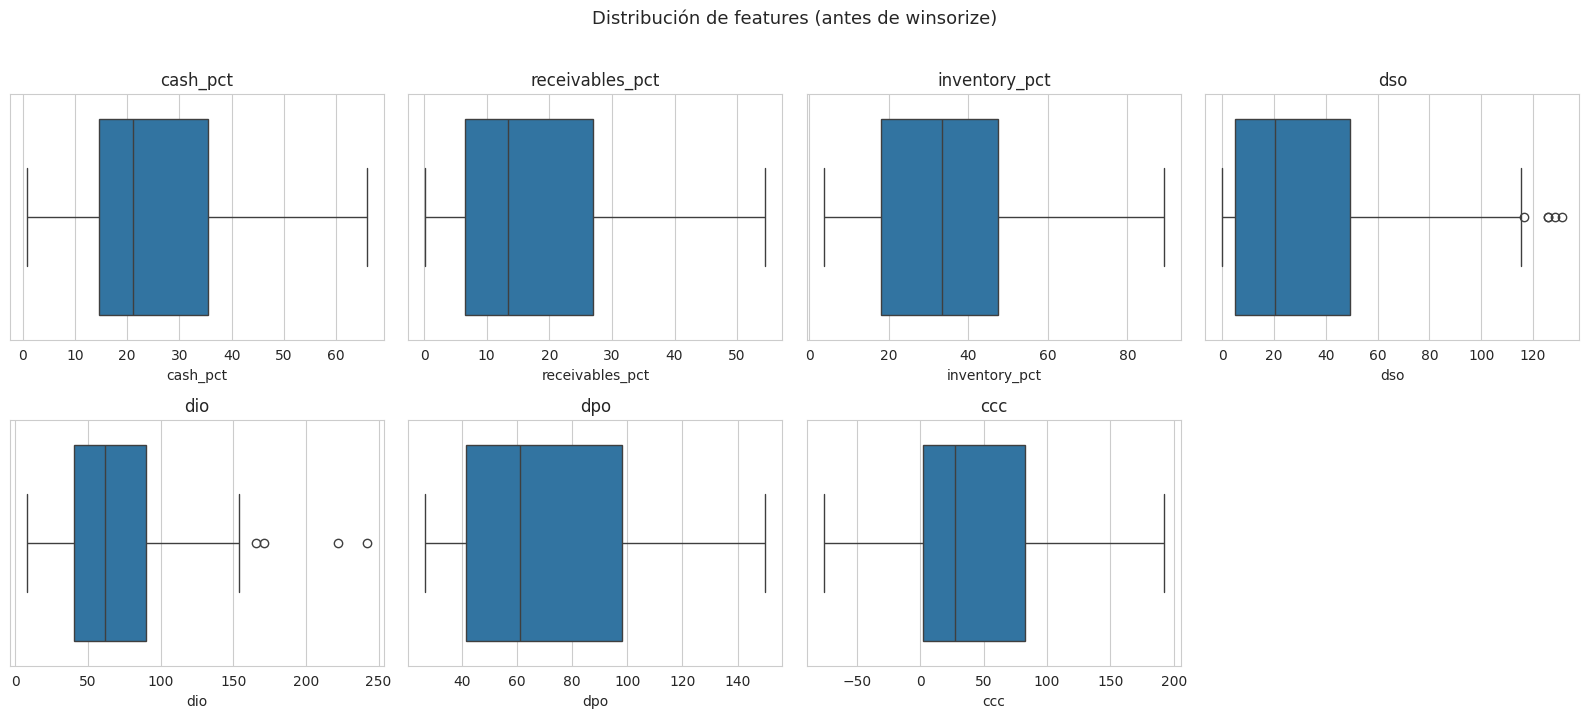

In [42]:
features = ['cash_pct', 'receivables_pct', 'inventory_pct', 'dso', 'dio', 'dpo', 'ccc']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
axes[-1].axis('off')
plt.suptitle('Distribución de features (antes de winsorize)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 6. Tratamiento de outliers: winsorización

Reemplazamos los valores en el 2.5% superior e inferior de cada variable por los percentiles 2.5 y 97.5, para que K-means (basado en distancias euclidianas) no se vea dominado por casos atípicos (ej. Tesla con DSO muy bajo, o algún año con AR inflado por una unidad atípica).


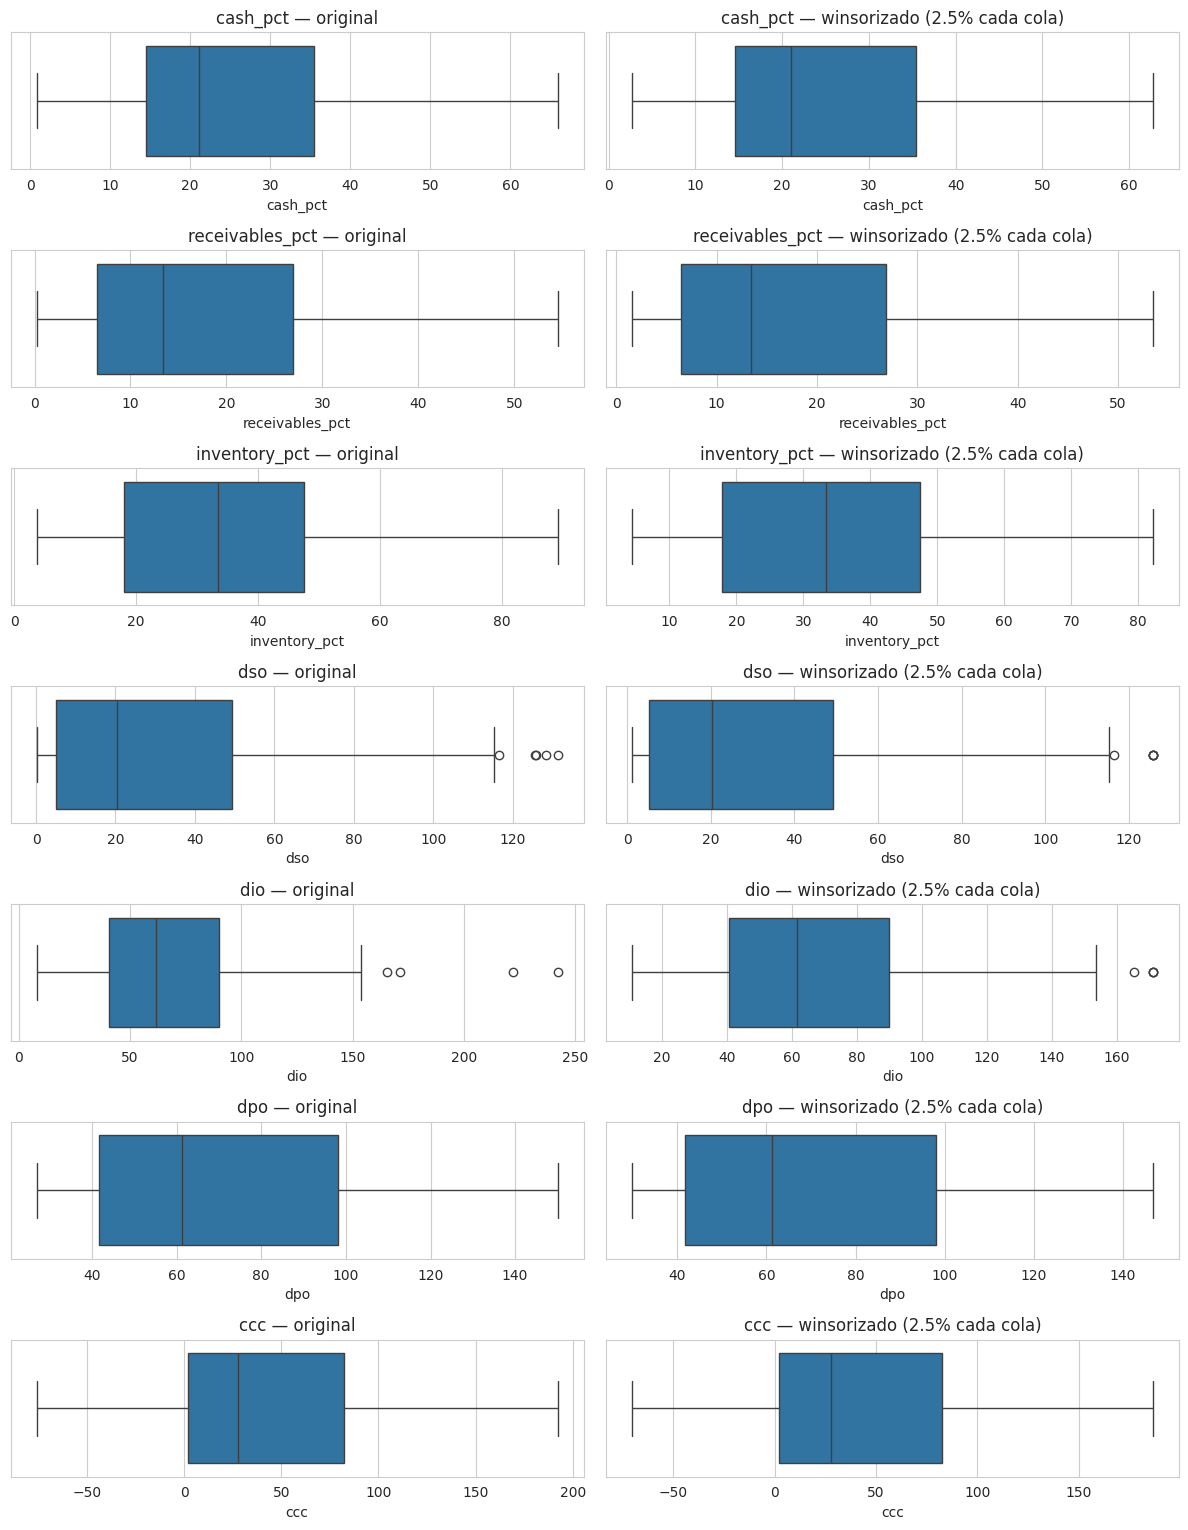

In [36]:
X_wins = df[features].copy()
for col in features:
    X_wins[col] = winsorize(X_wins[col], limits=[0.025, 0.025])

fig, axes = plt.subplots(len(features), 2, figsize=(12, 2.2*len(features)))
for i, col in enumerate(features):
    sns.boxplot(x=df[col], ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} — original')
    sns.boxplot(x=X_wins[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} — winsorizado (2.5% cada cola)')
plt.tight_layout()
plt.show()

## 7. Escalado robusto

`RobustScaler` usa mediana e IQR en lugar de media y desvío. Más apropiado para ratios financieros que aún tienen colas largas después de winsorizar.

In [43]:
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_wins), columns=features)
print('Resumen de features escaladas:')
print(X_scaled.describe().round(2))

Resumen de features escaladas:
       cash_pct  receivables_pct  inventory_pct    dso    dio    dpo    ccc
count     96.00            96.00          96.00  96.00  96.00  96.00  96.00
mean       0.19             0.24           0.07   0.31   0.23   0.16   0.13
std        0.70             0.72           0.74   0.84   0.86   0.59   0.74
min       -0.88            -0.58          -0.98  -0.44  -1.03  -0.56  -1.22
25%       -0.31            -0.34          -0.52  -0.34  -0.43  -0.35  -0.32
50%        0.00             0.00           0.00   0.00   0.00   0.00   0.00
75%        0.69             0.66           0.48   0.66   0.57   0.65   0.68
max        1.99             1.96           1.65   2.39   2.22   1.52   1.98


## 8. Selección del número de clusters (k)

Probamos k = 2 … 8 y miramos dos métricas:

- **Inercia (codo)**: suma de distancias al cuadrado dentro de cada cluster. Buscamos el punto donde sumar otro cluster ya no reduce mucho la inercia.
- **Silhouette**: cuán bien separados están los clusters (rango −1 a +1). Más alto = mejor.

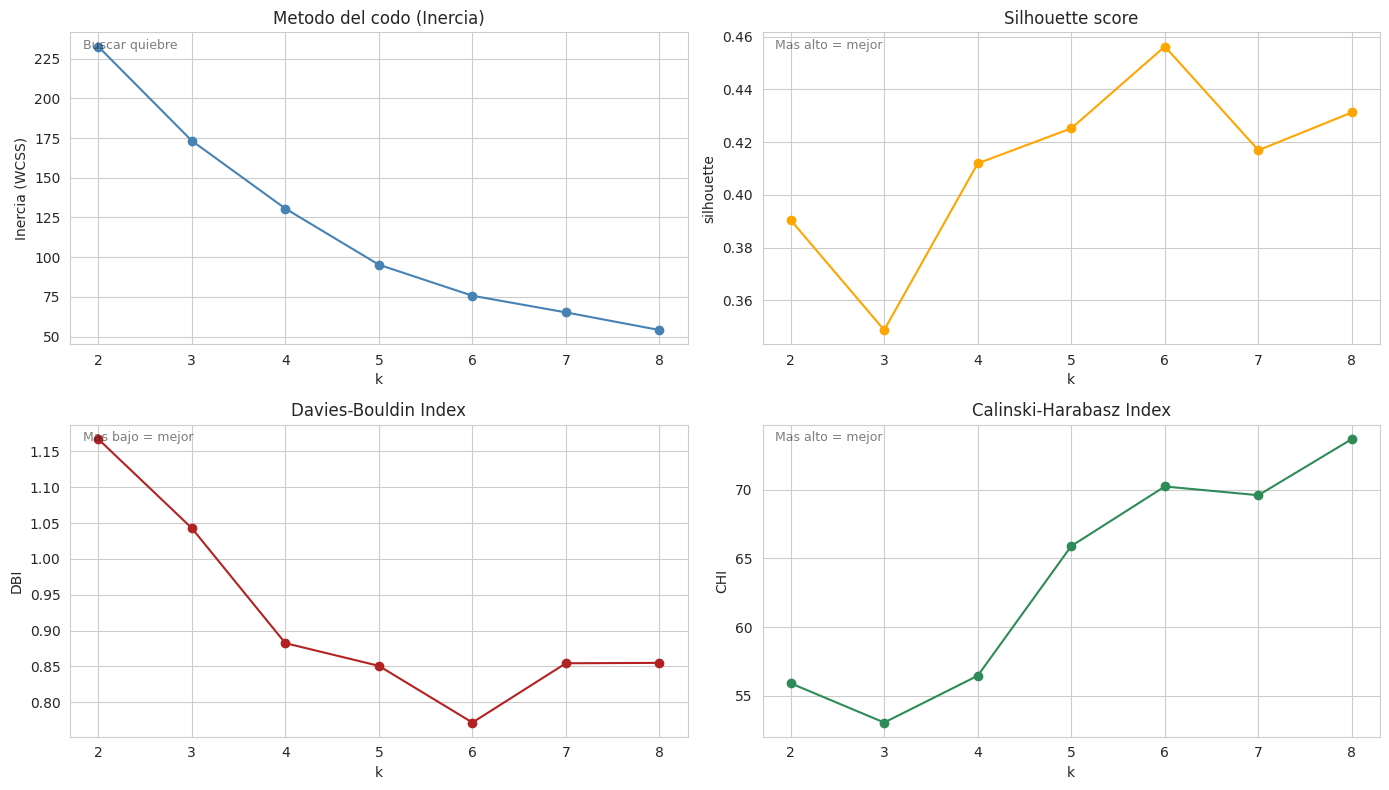

 k  inercia  silhouette  davies_bouldin  calinski_harabasz
 2  232.657       0.390           1.167             55.908
 3  173.312       0.349           1.043             53.049
 4  130.599       0.412           0.882             56.458
 5   95.222       0.425           0.851             65.895
 6   75.695       0.456           0.772             70.230
 7   65.188       0.417           0.854             69.595
 8   54.076       0.431           0.855             73.685

k sugerido por silhouette:        6
k sugerido por Davies-Bouldin:    6
k sugerido por Calinski-Harabasz: 8

k por voto mayoritario: 6 (2 de 3 metricas lo eligen)


In [55]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

K_range = range(2, 9)
inertias, silhouettes, db_scores, ch_scores = [], [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(list(K_range), inertias, marker='o', color='steelblue')
axes[0, 0].set_title('Metodo del codo (Inercia)')
axes[0, 0].set_xlabel('k'); axes[0, 0].set_ylabel('Inercia (WCSS)')
axes[0, 0].grid(True)
axes[0, 0].text(0.02, 0.98, 'Buscar quiebre', transform=axes[0, 0].transAxes,
                verticalalignment='top', fontsize=9, alpha=0.6)

axes[0, 1].plot(list(K_range), silhouettes, marker='o', color='orange')
axes[0, 1].set_title('Silhouette score')
axes[0, 1].set_xlabel('k'); axes[0, 1].set_ylabel('silhouette')
axes[0, 1].grid(True)
axes[0, 1].text(0.02, 0.98, 'Mas alto = mejor', transform=axes[0, 1].transAxes,
                verticalalignment='top', fontsize=9, alpha=0.6)

axes[1, 0].plot(list(K_range), db_scores, marker='o', color='firebrick')
axes[1, 0].set_title('Davies-Bouldin Index')
axes[1, 0].set_xlabel('k'); axes[1, 0].set_ylabel('DBI')
axes[1, 0].grid(True)
axes[1, 0].text(0.02, 0.98, 'Mas bajo = mejor', transform=axes[1, 0].transAxes,
                verticalalignment='top', fontsize=9, alpha=0.6)

axes[1, 1].plot(list(K_range), ch_scores, marker='o', color='seagreen')
axes[1, 1].set_title('Calinski-Harabasz Index')
axes[1, 1].set_xlabel('k'); axes[1, 1].set_ylabel('CHI')
axes[1, 1].grid(True)
axes[1, 1].text(0.02, 0.98, 'Mas alto = mejor', transform=axes[1, 1].transAxes,
                verticalalignment='top', fontsize=9, alpha=0.6)

plt.tight_layout()
plt.show()

resumen_k = pd.DataFrame({
    'k': list(K_range),
    'inercia': inertias,
    'silhouette': silhouettes,
    'davies_bouldin': db_scores,
    'calinski_harabasz': ch_scores,
}).round(3)

print(resumen_k.to_string(index=False))
print()

# Voto por mayoria entre las 3 metricas direccionales (silhouette alto, DB bajo, CH alto)
votos = {}
k_sil = int(resumen_k.loc[resumen_k['silhouette'].idxmax(), 'k'])
k_db  = int(resumen_k.loc[resumen_k['davies_bouldin'].idxmin(), 'k'])
k_ch  = int(resumen_k.loc[resumen_k['calinski_harabasz'].idxmax(), 'k'])
for k in (k_sil, k_db, k_ch):
    votos[k] = votos.get(k, 0) + 1

print(f'k sugerido por silhouette:        {k_sil}')
print(f'k sugerido por Davies-Bouldin:    {k_db}')
print(f'k sugerido por Calinski-Harabasz: {k_ch}')
print()
k_mayoritario = max(votos.items(), key=lambda x: x[1])
print(f'k por voto mayoritario: {k_mayoritario[0]} ({k_mayoritario[1]} de 3 metricas lo eligen)')


## 9. Elección final de k

Por defecto elegimos el k basado en las gráficas anteriores


In [57]:
optimal_k = 6

## 10. K-means final + visualización PCA

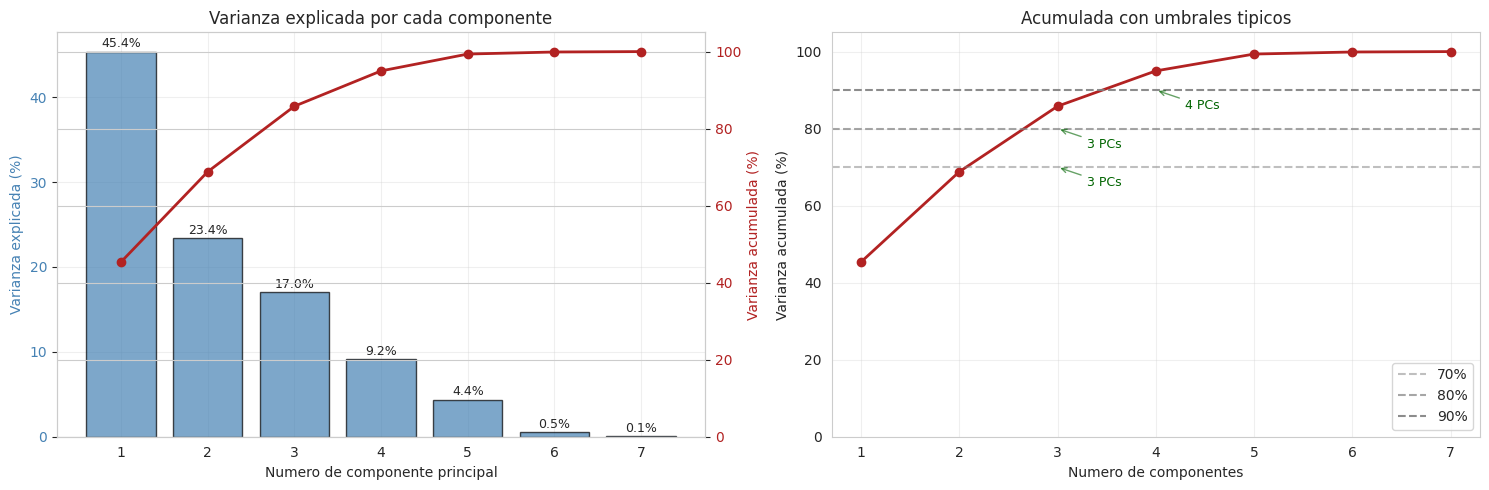

 PC  var_individual_%  var_acumulada_%
PC1             45.38            45.38
PC2             23.43            68.81
PC3             17.00            85.82
PC4              9.17            94.98
PC5              4.38            99.36
PC6              0.53            99.90
PC7              0.10           100.00

Para capturar >= 70%: 3 componentes (acumulado real: 85.82%)
Para capturar >= 80%: 3 componentes (acumulado real: 85.82%)
Para capturar >= 90%: 4 componentes (acumulado real: 94.98%)
Para capturar >= 95%: 5 componentes (acumulado real: 99.36%)


In [59]:
# Scree plot: cuanta varianza captura cada componente principal
# Permite decidir cuantos PCs son suficientes para representar los datos

# PCA con TODOS los componentes posibles (= numero de features = 7)
pca_full = PCA(n_components=len(features), random_state=42)
pca_full.fit(X_scaled)

var_individual = pca_full.explained_variance_ratio_         # varianza de cada PC
var_acumulada  = np.cumsum(var_individual)                  # varianza acumulada
n_components_range = range(1, len(features) + 1)

# --- Plot doble: barras individuales + linea acumulada ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel izquierdo: barras de varianza individual + linea acumulada superpuesta
ax1 = axes[0]
bars = ax1.bar(n_components_range, var_individual * 100,
               color='steelblue', alpha=0.7, edgecolor='black', label='Varianza individual')
ax1.set_xlabel('Numero de componente principal')
ax1.set_ylabel('Varianza explicada (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(list(n_components_range))
ax1.grid(True, alpha=0.3)

# Eje secundario con la acumulada
ax1b = ax1.twinx()
ax1b.plot(n_components_range, var_acumulada * 100,
          marker='o', color='firebrick', linewidth=2, label='Acumulada')
ax1b.set_ylabel('Varianza acumulada (%)', color='firebrick')
ax1b.tick_params(axis='y', labelcolor='firebrick')
ax1b.set_ylim(0, 105)

# Etiquetas sobre las barras
for i, (b, v) in enumerate(zip(bars, var_individual)):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
             f'{v*100:.1f}%', ha='center', fontsize=9)

ax1.set_title('Varianza explicada por cada componente')

# Panel derecho: solo la acumulada con umbrales
ax2 = axes[1]
ax2.plot(n_components_range, var_acumulada * 100,
         marker='o', color='firebrick', linewidth=2)
ax2.axhline(70, color='gray', linestyle='--', alpha=0.5, label='70%')
ax2.axhline(80, color='gray', linestyle='--', alpha=0.7, label='80%')
ax2.axhline(90, color='gray', linestyle='--', alpha=0.9, label='90%')
ax2.set_xlabel('Numero de componentes')
ax2.set_ylabel('Varianza acumulada (%)')
ax2.set_title('Acumulada con umbrales tipicos')
ax2.set_xticks(list(n_components_range))
ax2.set_ylim(0, 105)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='lower right')

# Anotacion: cuantas componentes para llegar a cada umbral
for umbral in (70, 80, 90):
    n_necesario = int(np.argmax(var_acumulada * 100 >= umbral)) + 1
    if var_acumulada[n_necesario - 1] * 100 >= umbral:
        ax2.annotate(f'{n_necesario} PCs', xy=(n_necesario, umbral),
                     xytext=(n_necesario + 0.3, umbral - 5),
                     fontsize=9, color='darkgreen',
                     arrowprops=dict(arrowstyle='->', color='darkgreen', alpha=0.6))

plt.tight_layout()
plt.show()

# --- Tabla resumen ---
resumen_pca = pd.DataFrame({
    'PC': [f'PC{i}' for i in n_components_range],
    'var_individual_%': (var_individual * 100).round(2),
    'var_acumulada_%':  (var_acumulada * 100).round(2),
})
print(resumen_pca.to_string(index=False))
print()

# Cuantas componentes necesitamos para cada umbral
for umbral in (70, 80, 90, 95):
    cumple = var_acumulada * 100 >= umbral
    if cumple.any():
        n = int(np.argmax(cumple)) + 1
        print(f'Para capturar >= {umbral}%: {n} componentes (acumulado real: {var_acumulada[n-1]*100:.2f}%)')
    else:
        print(f'Para capturar >= {umbral}%: ni con todos los componentes')


Distribucion de observaciones por cluster:
cluster
0    15
1    16
2    25
3     8
4    27
5     5
Name: count, dtype: int64

Varianza explicada por PC1/PC2/PC3: [0.454 0.234 0.17 ]
Acumulada total: 0.858

Loadings (contribucion de cada feature a PC1/PC2/PC3):
                   PC1    PC2    PC3
cash_pct        -0.116 -0.004  0.704
receivables_pct  0.451 -0.326 -0.160
inventory_pct   -0.336  0.378 -0.433
dso              0.598 -0.190 -0.154
dio              0.326  0.711  0.296
dpo              0.202 -0.121  0.385
ccc              0.408  0.442 -0.179



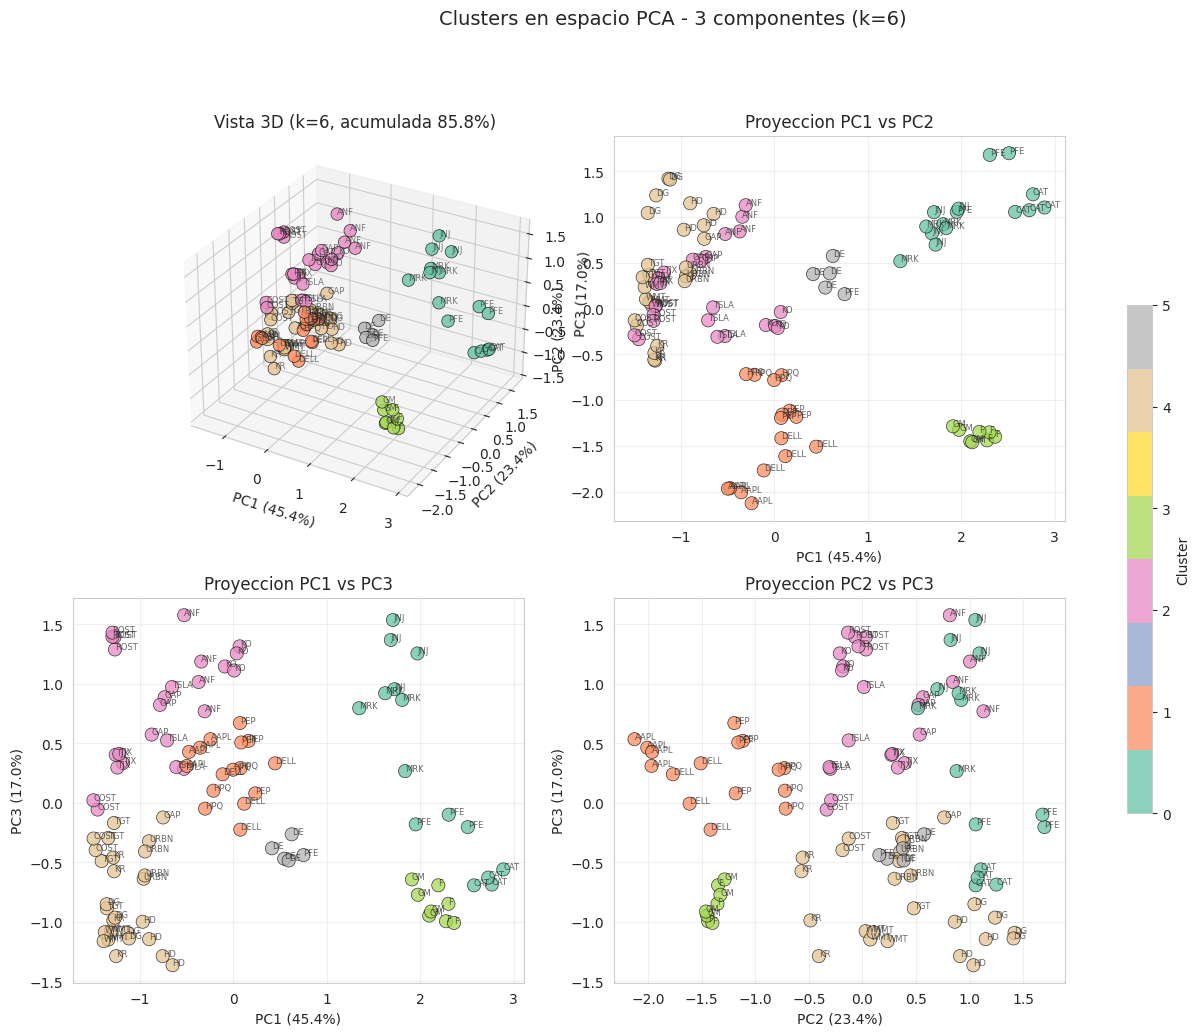

In [61]:
# K-means + PCA con 3 componentes (85.8% de varianza acumulada)
# Visualizacion: 1 vista 3D + 3 proyecciones 2D pareadas

from mpl_toolkits.mplot3d import Axes3D  # registra el backend 3D en matplotlib

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f'Distribucion de observaciones por cluster:\n{df["cluster"].value_counts().sort_index()}\n')

# --- PCA con 3 componentes ---
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'Varianza explicada por PC1/PC2/PC3: {pca.explained_variance_ratio_.round(3)}')
print(f'Acumulada total: {pca.explained_variance_ratio_.sum():.3f}\n')

loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2', 'PC3'], index=features).round(3)
print('Loadings (contribucion de cada feature a PC1/PC2/PC3):')
print(loadings)
print()

# --- Visualizacion: 1 panel 3D + 3 proyecciones 2D ---
fig = plt.figure(figsize=(16, 11))

# Panel principal: scatter 3D
ax_3d = fig.add_subplot(2, 2, 1, projection='3d')
ax_3d.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
              c=df['cluster'], cmap='Set2', s=80,
              alpha=0.8, edgecolors='black', linewidths=0.5)
ax_3d.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax_3d.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax_3d.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})')
ax_3d.set_title(f'Vista 3D (k={optimal_k}, acumulada {pca.explained_variance_ratio_.sum():.1%})')
# Anotaciones 3D (un poco caras en performance pero util para 96 puntos)
for i, row in df.reset_index().iterrows():
    ax_3d.text(X_pca[i, 0], X_pca[i, 1], X_pca[i, 2],
               row['ticker'], fontsize=6, alpha=0.6)

# Funcion auxiliar para los 3 paneles 2D
def plot_2d(ax, xi, yi, xlabel, ylabel, titulo):
    sc = ax.scatter(X_pca[:, xi], X_pca[:, yi],
                    c=df['cluster'], cmap='Set2', s=90,
                    alpha=0.75, edgecolors='black', linewidths=0.5)
    for i, row in df.reset_index().iterrows():
        ax.annotate(row['ticker'], (X_pca[i, xi], X_pca[i, yi]),
                    fontsize=6, alpha=0.7)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(titulo)
    ax.grid(True, alpha=0.3)
    return sc

# Panel 2: PC1 vs PC2 (la vista clasica)
ax_12 = fig.add_subplot(2, 2, 2)
plot_2d(ax_12, 0, 1,
        f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
        f'PC2 ({pca.explained_variance_ratio_[1]:.1%})',
        'Proyeccion PC1 vs PC2')

# Panel 3: PC1 vs PC3
ax_13 = fig.add_subplot(2, 2, 3)
plot_2d(ax_13, 0, 2,
        f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
        f'PC3 ({pca.explained_variance_ratio_[2]:.1%})',
        'Proyeccion PC1 vs PC3')

# Panel 4: PC2 vs PC3
ax_23 = fig.add_subplot(2, 2, 4)
sc_final = plot_2d(ax_23, 1, 2,
                   f'PC2 ({pca.explained_variance_ratio_[1]:.1%})',
                   f'PC3 ({pca.explained_variance_ratio_[2]:.1%})',
                   'Proyeccion PC2 vs PC3')

# Colorbar comun para los 3 paneles 2D
cbar = fig.colorbar(sc_final, ax=[ax_12, ax_13, ax_23], shrink=0.6, label='Cluster')

plt.suptitle(f'Clusters en espacio PCA - 3 componentes (k={optimal_k})', fontsize=14, y=0.995)
plt.show()


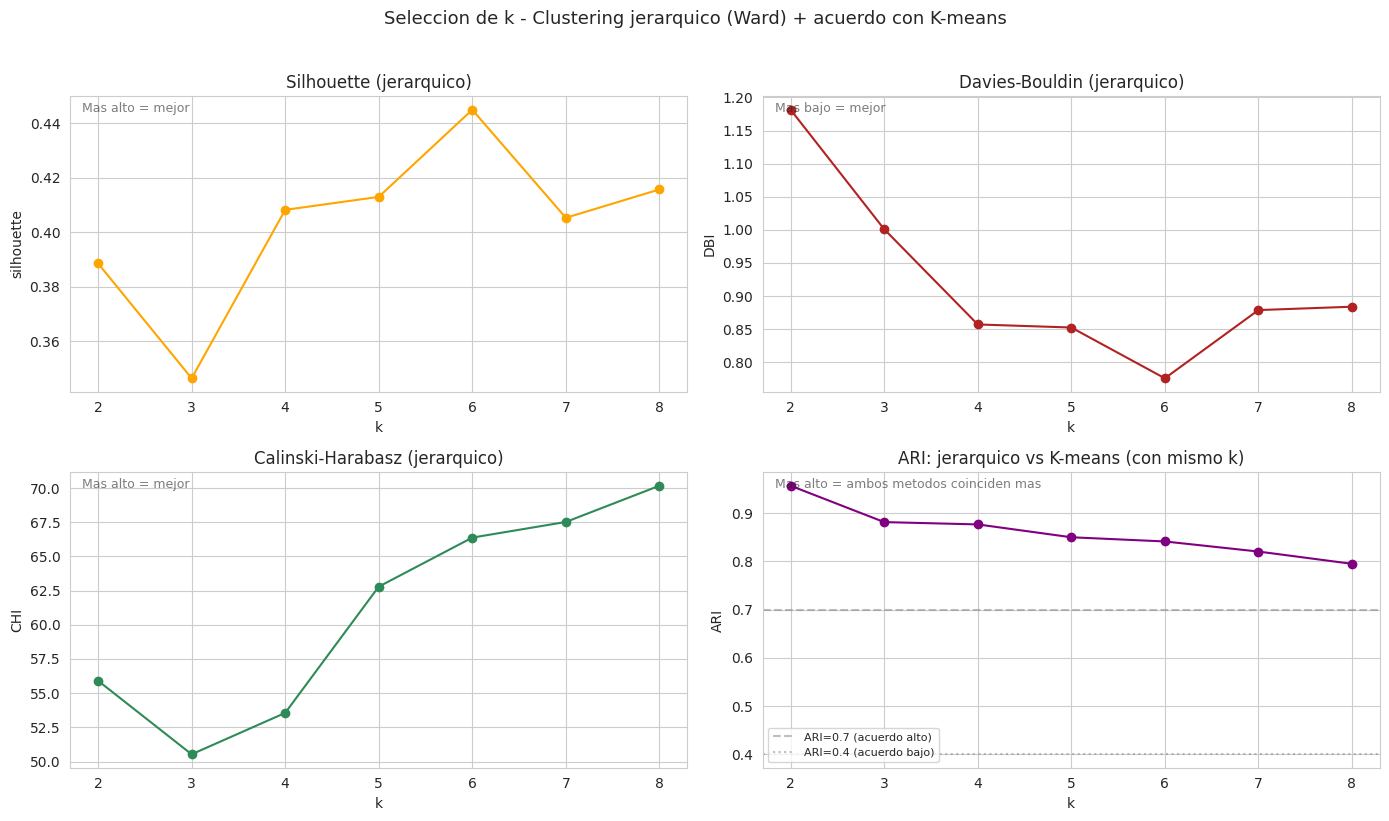

 k  silhouette_hier  davies_bouldin_hier  calinski_harabasz_hier  ARI_vs_kmeans
 2            0.388                1.181                  55.905          0.957
 3            0.346                1.001                  50.529          0.882
 4            0.408                0.857                  53.555          0.877
 5            0.413                0.853                  62.787          0.850
 6            0.445                0.776                  66.373          0.841
 7            0.405                0.879                  67.517          0.821
 8            0.416                0.884                  70.164          0.795

k sugerido por silhouette (jerarq.):       6
k sugerido por Davies-Bouldin (jerarq.):   6
k sugerido por Calinski-Harabasz (jerarq): 8
k con MAYOR acuerdo K-means vs jerarquico: 2

k por voto mayoritario (jerarquico):  6 (2/3 metricas)


In [69]:
# Seleccion de k para clustering jerarquico
# Mismo formato que el analisis de k de K-means + columna extra: ARI vs K-means

from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, fcluster

# Linkage matrix (una sola vez)
linked = linkage(X_scaled, method='ward')

K_range = range(2, 9)
sil_hier, db_hier, ch_hier, ari_vs_kmeans = [], [], [], []

for k in K_range:
    # Particion jerarquica para este k
    hier_labels = fcluster(linked, t=k, criterion='maxclust')

    # Metricas de calidad de la particion jerarquica
    sil_hier.append(silhouette_score(X_scaled, hier_labels))
    db_hier.append(davies_bouldin_score(X_scaled, hier_labels))
    ch_hier.append(calinski_harabasz_score(X_scaled, hier_labels))

    # ARI: comparar con K-means usando el mismo k
    km_k = KMeans(n_clusters=k, random_state=42, n_init=20)
    km_labels_k = km_k.fit_predict(X_scaled)
    ari_vs_kmeans.append(adjusted_rand_score(km_labels_k, hier_labels))

# --- Plot 2x2 ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(list(K_range), sil_hier, marker='o', color='orange')
axes[0, 0].set_title('Silhouette (jerarquico)')
axes[0, 0].set_xlabel('k'); axes[0, 0].set_ylabel('silhouette')
axes[0, 0].grid(True)
axes[0, 0].text(0.02, 0.98, 'Mas alto = mejor', transform=axes[0, 0].transAxes,
                verticalalignment='top', fontsize=9, alpha=0.6)

axes[0, 1].plot(list(K_range), db_hier, marker='o', color='firebrick')
axes[0, 1].set_title('Davies-Bouldin (jerarquico)')
axes[0, 1].set_xlabel('k'); axes[0, 1].set_ylabel('DBI')
axes[0, 1].grid(True)
axes[0, 1].text(0.02, 0.98, 'Mas bajo = mejor', transform=axes[0, 1].transAxes,
                verticalalignment='top', fontsize=9, alpha=0.6)

axes[1, 0].plot(list(K_range), ch_hier, marker='o', color='seagreen')
axes[1, 0].set_title('Calinski-Harabasz (jerarquico)')
axes[1, 0].set_xlabel('k'); axes[1, 0].set_ylabel('CHI')
axes[1, 0].grid(True)
axes[1, 0].text(0.02, 0.98, 'Mas alto = mejor', transform=axes[1, 0].transAxes,
                verticalalignment='top', fontsize=9, alpha=0.6)

axes[1, 1].plot(list(K_range), ari_vs_kmeans, marker='o', color='purple')
axes[1, 1].axhline(0.7, color='gray', linestyle='--', alpha=0.5, label='ARI=0.7 (acuerdo alto)')
axes[1, 1].axhline(0.4, color='gray', linestyle=':',  alpha=0.5, label='ARI=0.4 (acuerdo bajo)')
axes[1, 1].set_title('ARI: jerarquico vs K-means (con mismo k)')
axes[1, 1].set_xlabel('k'); axes[1, 1].set_ylabel('ARI')
axes[1, 1].grid(True)
axes[1, 1].legend(loc='lower left', fontsize=8)
axes[1, 1].text(0.02, 0.98, 'Mas alto = ambos metodos coinciden mas',
                transform=axes[1, 1].transAxes,
                verticalalignment='top', fontsize=9, alpha=0.6)

plt.suptitle('Seleccion de k - Clustering jerarquico (Ward) + acuerdo con K-means', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Tabla resumen ---
resumen_k_hier = pd.DataFrame({
    'k': list(K_range),
    'silhouette_hier': sil_hier,
    'davies_bouldin_hier': db_hier,
    'calinski_harabasz_hier': ch_hier,
    'ARI_vs_kmeans': ari_vs_kmeans,
}).round(3)

print(resumen_k_hier.to_string(index=False))
print()

# Sugerencias por metrica
k_sil = int(resumen_k_hier.loc[resumen_k_hier['silhouette_hier'].idxmax(), 'k'])
k_db  = int(resumen_k_hier.loc[resumen_k_hier['davies_bouldin_hier'].idxmin(), 'k'])
k_ch  = int(resumen_k_hier.loc[resumen_k_hier['calinski_harabasz_hier'].idxmax(), 'k'])
k_ari = int(resumen_k_hier.loc[resumen_k_hier['ARI_vs_kmeans'].idxmax(), 'k'])

print(f'k sugerido por silhouette (jerarq.):       {k_sil}')
print(f'k sugerido por Davies-Bouldin (jerarq.):   {k_db}')
print(f'k sugerido por Calinski-Harabasz (jerarq): {k_ch}')
print(f'k con MAYOR acuerdo K-means vs jerarquico: {k_ari}')
print()

# Voto entre las 3 metricas direccionales internas (sin contar ARI que mide consistencia)
votos = {}
for k in (k_sil, k_db, k_ch):
    votos[k] = votos.get(k, 0) + 1
k_mayoritario = max(votos.items(), key=lambda x: x[1])
print(f'k por voto mayoritario (jerarquico):  {k_mayoritario[0]} ({k_mayoritario[1]}/3 metricas)')


## 11. Validación con clustering jerárquico

Comparamos K-means con clustering jerárquico aglomerativo (linkage = ward) y cuantificamos el acuerdo entre ambos con el **Adjusted Rand Index (ARI)**.

- ARI = 1 → acuerdo perfecto
- ARI ≥ 0.7 → buena consistencia
- ARI ≤ 0.3 → métodos discrepan (revisar k o features)

In [ ]:
cluster_profile = df.groupby('cluster')[features].mean().round(2)
cluster_profile['n_obs'] = df.groupby('cluster').size()
cluster_profile['empresas'] = df.groupby('cluster')['ticker'].apply(lambda x: ', '.join(sorted(set(x))))

print('Centroides por cluster:')
print(cluster_profile[features + ['n_obs']])
print()
print('Empresas en cada cluster (con nombre completo):')
for c in sorted(cluster_profile.index):
    tickers_cluster = sorted(set(df[df['cluster'] == c]['ticker']))
    nombres = [nombre_empresa(tk) for tk in tickers_cluster]
    print(f'  Cluster {c}:')
    for n in nombres:
        print(f'    - {n}')

plt.figure(figsize=(10, max(4, optimal_k * 0.8)))
sns.heatmap(cluster_profile[features], annot=True, fmt='.1f', cmap='RdBu_r', center=0)
plt.title('Perfil financiero por cluster (centroides)')
plt.tight_layout(); plt.show()


## 12. Perfil de cada cluster

Los centroides (promedio de features por cluster) dicen qué tipo de empresa representa cada grupo. Interpretación financiera:

- **DSO bajo + DPO alto + CCC negativo** → caja muy eficiente (cobra rápido, paga lento).

- **DIO alto** → inventario lento. Autos, industriales, retail tradicional.
- **DSO alto** → mucha venta a crédito. B2B, industriales, farma.
- **Cash_pct alto** → conservadora, mantiene liquidez.

In [ ]:
cluster_eficiente = int(cluster_profile['ccc'].idxmin())
ccc_objetivo = float(cluster_profile.loc[cluster_eficiente, 'ccc'])
tickers_eficientes = sorted(set(df[df['cluster'] == cluster_eficiente]['ticker']))

print(f'Cluster mas eficiente: {cluster_eficiente}')
print(f'  CCC promedio: {ccc_objetivo:.1f} dias')
print(f'  Empresas:')
for tk in tickers_eficientes:
    print(f'    - {nombre_empresa(tk)}')


## 13. Cluster más eficiente

Definimos al cluster más eficiente como el de **menor CCC promedio**. Es la métrica directa de gestión de capital de trabajo según el marco teórico.

In [49]:
cluster_eficiente = int(cluster_profile['ccc'].idxmin())
ccc_objetivo = float(cluster_profile.loc[cluster_eficiente, 'ccc'])
print(f'Cluster más eficiente: {cluster_eficiente}')
print(f'  CCC promedio: {ccc_objetivo:.1f} días')
print(f'  Empresas: {cluster_profile.loc[cluster_eficiente, "empresas"]}')

Cluster más eficiente: 1
  CCC promedio: -39.5 días
  Empresas: AAPL, DELL, HPQ, PEP


# Aplicar a la ultima observacion de cada empresa
ultima_por_empresa = df.sort_values("fiscal_year").drop_duplicates("ticker", keep="last")

resultados = [predecir_niveles_optimos(row, targets_por_cluster) for _, row in ultima_por_empresa.iterrows()]
df_resultados = pd.DataFrame(resultados)

# Agregar columna con nombre completo
df_resultados.insert(1, "empresa", df_resultados["ticker"].map(lambda tk: COMPANY_NAMES.get(tk, tk)))

# Vista 1: ratios actuales vs target (dias)
vista_ratios = df_resultados[["ticker", "empresa", "cluster",
                              "dio_actual", "dio_target",
                              "dso_actual", "dso_target",
                              "dpo_actual", "dpo_target",
                              "ccc_actual", "ccc_target"]].round(1)
print("=== Ratios actuales vs target (dias) ===")
print(vista_ratios.to_string(index=False))

# Vista 2: niveles absolutos en USD millones
vista_dolares = df_resultados[["ticker", "empresa", "cluster",
                               "inv_actual", "inv_optimo", "inv_gap",
                               "ar_actual",  "ar_optimo",  "ar_gap",
                               "ap_actual",  "ap_optimo",  "ap_gap"]].copy()
for c in vista_dolares.columns:
    if c not in ["ticker", "empresa", "cluster"]:
        vista_dolares[c] = (vista_dolares[c] / 1e6).round(0)
vista_dolares.columns = ["ticker", "empresa", "cluster",
                         "inv_act_M", "inv_opt_M", "inv_gap_M",
                         "AR_act_M",  "AR_opt_M",  "AR_gap_M",
                         "AP_act_M",  "AP_opt_M",  "AP_gap_M"]
print()
print("=== Niveles absolutos en USD millones (gap positivo = sobra capital atrapado) ===")
print(vista_dolares.to_string(index=False))


In [50]:
def calcular_targets_por_cluster(df, top_pct=0.30):
    """Para cada cluster, calcula los target ratios (DIO/DSO/DPO/CCC)
    como la mediana del top-30% por menor CCC.
    """
    targets = {}
    for c in sorted(df["cluster"].unique()):
        sub = df[df["cluster"] == c]
        n_top = max(3, int(len(sub) * top_pct))
        top = sub.nsmallest(n_top, "ccc")
        targets[c] = {
            "dio_target": float(top["dio"].median()),
            "dso_target": float(top["dso"].median()),
            "dpo_target": float(top["dpo"].median()),
            "ccc_target": float(top["ccc"].median()),
            "n_train": n_top,
        }
    return targets


def predecir_niveles_optimos(empresa_row, targets_por_cluster):
    """Calcula niveles optimos absolutos usando target ratios x revenue/COGS actuales."""
    c = int(empresa_row["cluster"])
    t = targets_por_cluster[c]

    cogs = float(empresa_row["cogs"])
    revenue = float(empresa_row["revenue"])

    inv_optimo = t["dio_target"] * cogs / 365
    ar_optimo  = t["dso_target"] * revenue / 365
    ap_optimo  = t["dpo_target"] * cogs / 365

    inv_actual = float(empresa_row["inventory"])
    ar_actual  = float(empresa_row["accounts_receivable"])
    ap_actual  = float(empresa_row["accounts_payable"])

    return {
        "ticker": empresa_row["ticker"],
        "fiscal_year": int(empresa_row["fiscal_year"]),
        "cluster": c,
        "dio_actual": float(empresa_row["dio"]),
        "dio_target": t["dio_target"],
        "dso_actual": float(empresa_row["dso"]),
        "dso_target": t["dso_target"],
        "dpo_actual": float(empresa_row["dpo"]),
        "dpo_target": t["dpo_target"],
        "ccc_actual": float(empresa_row["ccc"]),
        "ccc_target": t["ccc_target"],
        "inv_actual": inv_actual, "inv_optimo": inv_optimo, "inv_gap": inv_actual - inv_optimo,
        "ar_actual":  ar_actual,  "ar_optimo":  ar_optimo,  "ar_gap":  ar_actual - ar_optimo,
        "ap_actual":  ap_actual,  "ap_optimo":  ap_optimo,  "ap_gap":  ap_actual - ap_optimo,
    }


targets_por_cluster = calcular_targets_por_cluster(df, top_pct=0.30)
print("Targets por cluster (mediana del top-30% por menor CCC):")
header = f"{'cluster':>8} {'DIO_t':>8} {'DSO_t':>8} {'DPO_t':>8} {'CCC_t':>8} {'n_train':>8}"
print(header)
for c, t in targets_por_cluster.items():
    print(f"{c:>8} {t['dio_target']:>8.1f} {t['dso_target']:>8.1f} {t['dpo_target']:>8.1f} {t['ccc_target']:>8.1f} {t['n_train']:>8}")


Targets por cluster (mediana del top-30% por menor CCC):
 cluster    DIO_t    DSO_t    DPO_t    CCC_t  n_train
       0    153.0     62.4    134.7     87.2        4
       1     10.1     29.6    111.1    -70.8        4
       2     77.3     13.2     91.9      2.0        7
       3     39.4    109.3     67.2     81.4        3
       4     27.1      5.3     33.2     -0.4        8
       5     84.7     39.5     33.4     91.9        3


In [51]:
# Aplicar a la ultima observacion de cada empresa
ultima_por_empresa = df.sort_values("fiscal_year").drop_duplicates("ticker", keep="last")

resultados = [predecir_niveles_optimos(row, targets_por_cluster) for _, row in ultima_por_empresa.iterrows()]
df_resultados = pd.DataFrame(resultados)

# Vista 1: ratios actuales vs target (dias)
vista_ratios = df_resultados[["ticker", "cluster",
                              "dio_actual", "dio_target",
                              "dso_actual", "dso_target",
                              "dpo_actual", "dpo_target",
                              "ccc_actual", "ccc_target"]].round(1)
print("=== Ratios actuales vs target (dias) ===")
print(vista_ratios.to_string(index=False))

# Vista 2: niveles absolutos en USD millones
vista_dolares = df_resultados[["ticker", "cluster",
                               "inv_actual", "inv_optimo", "inv_gap",
                               "ar_actual",  "ar_optimo",  "ar_gap",
                               "ap_actual",  "ap_optimo",  "ap_gap"]].copy()
for c in vista_dolares.columns:
    if c not in ["ticker", "cluster"]:
        vista_dolares[c] = (vista_dolares[c] / 1e6).round(0)
vista_dolares.columns = ["ticker", "cluster",
                         "inv_act_M", "inv_opt_M", "inv_gap_M",
                         "AR_act_M",  "AR_opt_M",  "AR_gap_M",
                         "AP_act_M",  "AP_opt_M",  "AP_gap_M"]
print()
print("=== Niveles absolutos en USD millones (gap positivo = sobra capital atrapado) ===")
print(vista_dolares.to_string(index=False))


=== Ratios actuales vs target (dias) ===
ticker  cluster  dio_actual  dio_target  dso_actual  dso_target  dpo_actual  dpo_target  ccc_actual  ccc_target
  COST        2        27.6        77.3         4.2        13.2        30.1        91.9         1.7         2.0
   PFE        0       242.0       153.0        69.3        62.4       119.0       134.7       192.2        87.2
    DE        5        96.6        84.7        44.0        39.5        38.4        33.4       102.2        91.9
   HPQ        1        70.8        10.1        37.6        29.6       150.1       111.1       -41.7       -70.8
     F        3        30.1        39.4       125.8       109.4        50.8        67.2       105.1        81.4
    GM        3        30.4        39.4       115.0       109.4        50.3        67.2        95.2        81.4
  AAPL        1         9.4        10.1        34.9        29.6       115.4       111.1       -71.1       -70.8
  TSLA        2        58.2        77.3        17.6        13.2

---
# MODULO 3 - Simulador 'que pasa si'

Sliders para ajustar DIO, DSO y DPO de una empresa, y ver:

1. **CCC nuevo** = DIO + DSO - DPO
2. **Cash liberado** ~ delta_CCC x (revenue / 365)
3. **Receta sugerida** para llegar al target del **propio cluster** (no al cluster eficiente global, que seria irrealista para industrias muy distintas).

**Fixes respecto a la version previa**:
- Target = top-30% del **propio cluster** de la empresa. CAT no se compara con AAPL.
- Limites fisicos en la receta: `DIO >= 5`, `DSO >= 0`, `DPO en [5, 120]`. No mas dias negativos ni DPO de 200 dias.
- Si las 3 palancas tocan limite y aun queda brecha, se reporta como **brecha estructural**: no se puede cerrar solo con palancas operativas.


In [73]:
import ipywidgets as widgets
from IPython.display import display


def simular(ticker="WMT"):
    if ticker not in df["ticker"].values:
        print("Ticker", ticker, "no esta en el dataset.")
        print("Disponibles:", sorted(df["ticker"].unique()))
        return

    emp = df[df["ticker"] == ticker].sort_values("fiscal_year").iloc[-1]
    dio_a = float(emp["dio"])
    dso_a = float(emp["dso"])
    dpo_a = float(emp["dpo"])
    ccc_a = float(emp["ccc"])
    rev = float(emp["revenue"])
    cogs = float(emp["cogs"])
    inv_a = float(emp["inventory"])
    ar_a  = float(emp["accounts_receivable"])
    ap_a  = float(emp["accounts_payable"])
    c = int(emp["cluster"])

    t = targets_por_cluster[c]
    dio_t = t["dio_target"]
    dso_t = t["dso_target"]
    dpo_t = t["dpo_target"]
    ccc_t = dio_t + dso_t - dpo_t

    # Niveles optimos en USD (despeje algebraico de DIO/DSO/DPO)
    inv_opt = dio_t * cogs    / 365
    ar_opt  = dso_t * rev     / 365
    ap_opt  = dpo_t * cogs    / 365

    # Valor en USD de UN dia de cada palanca (sensibilidad)
    usd_dia_inv = cogs / 365   # 1 dia de DIO = 1 dia de COGS en inventario
    usd_dia_ar  = rev  / 365   # 1 dia de DSO = 1 dia de revenue en AR
    usd_dia_ap  = cogs / 365   # 1 dia de DPO = 1 dia de COGS en AP

    dio_s = widgets.FloatSlider(value=dio_a, min=0, max=500, step=1,
                                description="DIO:", continuous_update=False,
                                style={"description_width": "60px"},
                                layout=widgets.Layout(width="500px"))
    dso_s = widgets.FloatSlider(value=dso_a, min=0, max=300, step=1,
                                description="DSO:", continuous_update=False,
                                style={"description_width": "60px"},
                                layout=widgets.Layout(width="500px"))
    dpo_s = widgets.FloatSlider(value=dpo_a, min=0, max=300, step=1,
                                description="DPO:", continuous_update=False,
                                style={"description_width": "60px"},
                                layout=widgets.Layout(width="500px"))

    out = widgets.Output()

    def _palanca(nombre, actual, target, mejor_baja, usd_por_dia):
        """Imprime UNA recomendacion por palanca."""
        if mejor_baja:
            diff = actual - target            # positivo = hay que bajar
            verbo = "Bajar"
        else:
            diff = target - actual            # positivo = hay que subir
            verbo = "Subir"

        if diff > 1:
            usd_efecto = diff * usd_por_dia / 1e6
            print(f"  {verbo} {nombre} en {diff:5.1f} dias -> {nombre} objetivo = {target:5.1f}  (libera ~${usd_efecto:,.0f}M USD)")
            return 1
        elif diff < -1:
            print(f"  {nombre}: tu nivel ({actual:.1f}d) ya es mejor que el target ({target:.1f}d). Mantener.")
            return 0
        else:
            print(f"  {nombre}: alineado con el target ({actual:.1f}d vs {target:.1f}d). Sin accion necesaria.")
            return 0

    def _mostrar(DIO, DSO, DPO):
        with out:
            out.clear_output(wait=True)
            ccc_n = DIO + DSO - DPO
            cash_liberado = (ccc_a - ccc_n) * (rev / 365)

            sector = emp["sector"]
            anio = int(emp["fiscal_year"])
            print(f"Empresa: {ticker} | Sector: {sector} | Cluster: {c} | Anio: {anio}")
            rev_b = rev / 1e9
            cogs_b = cogs / 1e9
            print(f"Revenue: ${rev_b:.2f}B   |   COGS: ${cogs_b:.2f}B")
            print()
            print("--- Tabla de ratios (dias) ---")
            print("               ACTUAL     NUEVO    Delta    TARGET cluster")
            print(f"  DIO        {dio_a:7.1f}   {DIO:7.1f}    {DIO-dio_a:+7.1f}   {dio_t:7.1f}")
            print(f"  DSO        {dso_a:7.1f}   {DSO:7.1f}    {DSO-dso_a:+7.1f}   {dso_t:7.1f}")
            print(f"  DPO        {dpo_a:7.1f}   {DPO:7.1f}    {DPO-dpo_a:+7.1f}   {dpo_t:7.1f}")
            print(f"  CCC        {ccc_a:7.1f}   {ccc_n:7.1f}    {ccc_n-ccc_a:+7.1f}   {ccc_t:7.1f}")
            print()
            print("--- Niveles en USD millones (actual vs optimo del cluster) ---")
            print("               ACTUAL       OPTIMO       BRECHA (sobra/falta)")
            print(f"  Inventario  ${inv_a/1e6:>9,.0f}M  ${inv_opt/1e6:>9,.0f}M  ${(inv_a-inv_opt)/1e6:>+9,.0f}M")
            print(f"  AR (cobrar) ${ar_a/1e6:>9,.0f}M  ${ar_opt/1e6:>9,.0f}M  ${(ar_a-ar_opt)/1e6:>+9,.0f}M")
            print(f"  AP (pagar)  ${ap_a/1e6:>9,.0f}M  ${ap_opt/1e6:>9,.0f}M  ${(ap_a-ap_opt)/1e6:>+9,.0f}M")
            print()
            cash_m = cash_liberado / 1e6
            if cash_liberado >= 0:
                print(f">> Cash liberado con TU simulacion (sliders): +${cash_m:,.0f}M USD")
            else:
                print(f"!! Cash atrapado adicional con TU simulacion: ${abs(cash_m):,.0f}M USD")
            print()

            print(f"--- Receta para llegar al target del cluster {c} ---")
            cambios = 0
            cambios += _palanca("DIO", dio_a, dio_t, mejor_baja=True,  usd_por_dia=usd_dia_inv)
            cambios += _palanca("DSO", dso_a, dso_t, mejor_baja=True,  usd_por_dia=usd_dia_ar)
            cambios += _palanca("DPO", dpo_a, dpo_t, mejor_baja=False, usd_por_dia=usd_dia_ap)

            if cambios == 0:
                print()
                print("  OK: estas alineado con el target del cluster en las 3 palancas.")

            # Brecha estructural: vs cluster global mas eficiente
            ccc_eficiente_global = float(cluster_profile.loc[cluster_eficiente, "ccc"])
            brecha_estructural = ccc_t - ccc_eficiente_global
            if brecha_estructural > 10:
                print()
                print(f"  >> Aun llegando al target operativo de tu cluster (CCC={ccc_t:.0f}d),")
                print(f"     quedan {brecha_estructural:.0f} dias de brecha vs cluster mas eficiente (CCC={ccc_eficiente_global:.0f}d).")
                print(f"     Esa brecha es ESTRUCTURAL: requiere cambiar modelo de negocio, no solo palancas operativas.")

    salida = widgets.interactive_output(_mostrar, {"DIO": dio_s, "DSO": dso_s, "DPO": dpo_s})
    ui = widgets.VBox([dio_s, dso_s, dpo_s])
    display(ui, out)


def simular_estatico(ticker="WMT", DIO=None, DSO=None, DPO=None):
    if ticker not in df["ticker"].values:
        print("Ticker", ticker, "no esta. Disponibles:", sorted(df["ticker"].unique()))
        return
    emp = df[df["ticker"] == ticker].sort_values("fiscal_year").iloc[-1]
    dio_a, dso_a, dpo_a = float(emp["dio"]), float(emp["dso"]), float(emp["dpo"])
    ccc_a, rev = float(emp["ccc"]), float(emp["revenue"])
    cogs = float(emp["cogs"])
    inv_a = float(emp["inventory"])
    ar_a  = float(emp["accounts_receivable"])
    ap_a  = float(emp["accounts_payable"])
    c = int(emp["cluster"])

    DIO_n = DIO if DIO is not None else dio_a
    DSO_n = DSO if DSO is not None else dso_a
    DPO_n = DPO if DPO is not None else dpo_a
    ccc_n = DIO_n + DSO_n - DPO_n
    cash_liberado = (ccc_a - ccc_n) * (rev / 365)

    t = targets_por_cluster[c]
    dio_t, dso_t, dpo_t = t["dio_target"], t["dso_target"], t["dpo_target"]
    ccc_t = dio_t + dso_t - dpo_t

    inv_opt = dio_t * cogs / 365
    ar_opt  = dso_t * rev  / 365
    ap_opt  = dpo_t * cogs / 365

    rev_b = rev / 1e9
    print(f"Empresa: {ticker} | Cluster: {c} | Revenue: ${rev_b:.2f}B")
    print()
    print("               ACTUAL     NUEVO    Delta    TARGET")
    print(f"  DIO        {dio_a:7.1f}   {DIO_n:7.1f}    {DIO_n-dio_a:+7.1f}   {dio_t:7.1f}")
    print(f"  DSO        {dso_a:7.1f}   {DSO_n:7.1f}    {DSO_n-dso_a:+7.1f}   {dso_t:7.1f}")
    print(f"  DPO        {dpo_a:7.1f}   {DPO_n:7.1f}    {DPO_n-dpo_a:+7.1f}   {dpo_t:7.1f}")
    print(f"  CCC        {ccc_a:7.1f}   {ccc_n:7.1f}    {ccc_n-ccc_a:+7.1f}   {ccc_t:7.1f}")
    print()
    print("Niveles en USD millones:")
    print(f"  Inventario  ${inv_a/1e6:>9,.0f}M  ->  optimo ${inv_opt/1e6:>9,.0f}M  (brecha ${(inv_a-inv_opt)/1e6:>+9,.0f}M)")
    print(f"  AR (cobrar) ${ar_a/1e6:>9,.0f}M  ->  optimo ${ar_opt/1e6:>9,.0f}M  (brecha ${(ar_a-ar_opt)/1e6:>+9,.0f}M)")
    print(f"  AP (pagar)  ${ap_a/1e6:>9,.0f}M  ->  optimo ${ap_opt/1e6:>9,.0f}M  (brecha ${(ap_a-ap_opt)/1e6:>+9,.0f}M)")
    print()
    cash_m = cash_liberado / 1e6
    if cash_liberado >= 0:
        print(f">> Cash liberado: +${cash_m:,.0f}M USD")
    else:
        print(f"!! Cash atrapado: ${abs(cash_m):,.0f}M USD")


# Editar ticker para probar otras empresas (ej. "TSLA", "CAT", "AAPL", "F", etc.)
simular(ticker="WMT")

# Fallback sin widgets:
# simular_estatico("WMT", DIO=40, DSO=5, DPO=60)
